# **SOM :SELF_ORANIZING_MAP**



**Importing libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**Importing** **Dataset**

In [3]:
dataset=pd.read_csv('Credit_Card_Applications.csv')
X=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values

**Feature Scaling**

In [4]:
from sklearn.preprocessing import MinMaxScaler
sc=MinMaxScaler(feature_range=(0,1))
X=sc.fit_transform(X)

**Training the SOM**

In [6]:
!pip install minisom


  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=5868306d7b12adba659e0f52475316908cd111b66aa48fb813de1998b205064b
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


In [7]:
from minisom import MiniSom
som=MiniSom(x=10,y=10,input_len=15,sigma=1.0,learning_rate=0.5)
som.random_weights_init(X)
som.train_random(data=X,num_iteration=100)

**Visualizing the result**

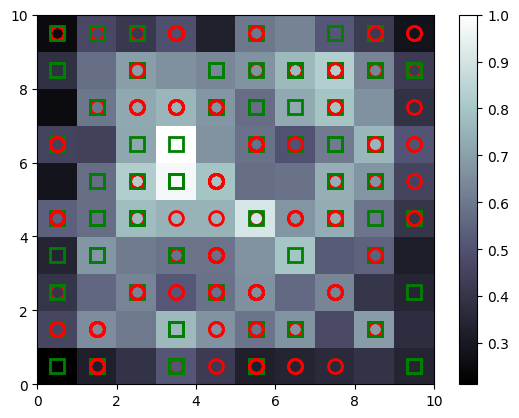

In [10]:
from pylab import bone,pcolor,colorbar,plot,show
bone()
pcolor(som.distance_map().T)
colorbar()
markers=['o','s']
colors=['r','g']
for i,x in enumerate(X):
  w=som.winner(x)
  plot(w[0]+0.5,w[1]+0.5,markers[y[i]],markeredgecolor=colors[y[i]],markerfacecolor='None',markersize=10,markeredgewidth=2)
show()

**Finding the frauds**

In [11]:
mapping = som.win_map(X)
frauds = np.concatenate((mapping[(8,1)], mapping[(6,8)]), axis = 0)
frauds = sc.inverse_transform(frauds)

In [14]:
from IPython.display import display


fraud_df = pd.DataFrame(frauds, columns=dataset.drop('Class', axis=1).columns)
display(fraud_df)

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
0,15683168.0,1.0,29.58,4.500,2.0,9.0,4.0,7.500,1.0,1.0,2.0,1.0,2.0,330.0,1.0
1,15618410.0,1.0,23.08,2.500,2.0,8.0,4.0,1.085,1.0,1.0,11.0,1.0,2.0,60.0,2185.0
2,15678882.0,1.0,39.58,13.915,2.0,9.0,4.0,8.625,1.0,1.0,6.0,1.0,2.0,70.0,1.0
3,15617348.0,1.0,63.33,0.540,2.0,8.0,4.0,0.585,1.0,1.0,3.0,1.0,2.0,180.0,1.0
4,15682860.0,1.0,27.83,1.500,2.0,9.0,4.0,2.000,1.0,1.0,11.0,1.0,2.0,434.0,36.0
5,15671769.0,1.0,56.75,12.250,2.0,7.0,4.0,1.250,1.0,1.0,4.0,1.0,2.0,200.0,1.0
6,15765257.0,1.0,22.75,11.000,2.0,11.0,4.0,2.500,1.0,1.0,7.0,1.0,2.0,100.0,810.0
7,15764226.0,1.0,25.75,0.500,2.0,8.0,4.0,1.460,1.0,1.0,5.0,1.0,2.0,312.0,1.0
8,15621423.0,1.0,25.67,12.500,2.0,13.0,4.0,1.210,1.0,1.0,67.0,1.0,2.0,140.0,259.0
9,15774262.0,1.0,29.25,14.790,2.0,6.0,4.0,5.040,1.0,1.0,5.0,1.0,2.0,168.0,1.0
